In [1]:
%load_ext watermark

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tcspc_sim import SimSample, SimFalcon, PhasorPlot
%watermark -v -p matplotlib,numpy

Python implementation: CPython
Python version       : 3.7.4
IPython version      : 7.20.0

matplotlib: 3.3.2
numpy     : 1.19.2



In [19]:
lifetimes = [4.0, 1.0, 0.2]
fractions = [80, 10, 10]
fractionnames = ['donor', 'AF long', 'AF short']
simSample = SimSample(lifetimes, fractions, fractionnames)
print(simSample)

Sample contains the following lifetimes:
  * donor : 4.00ns - 80.00% of photons
  * AF long : 1.00ns - 10.00% of photons
  * AF short : 0.20ns - 10.00% of photons


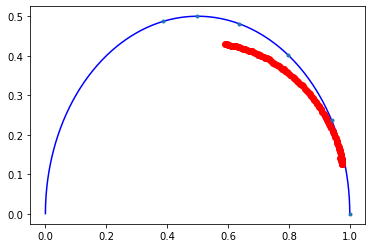

In [24]:
quenching = np.linspace(0,1,100)
simFalcon = SimFalcon([0])
x_coords = []
y_coords = []
for q in quenching:
    qv = [q,0,0]
    simSample.set_quenching(qv)
    photons,npht = simSample.generate_photons(1e5)
    simFalcon.setphotons(photons)
    x,y = simFalcon.getphasorcoordinates()
    x_coords.append(x)
    y_coords.append(y)

phasorPlot = PhasorPlot(simFalcon.getomega(),np.array([0,1,2,3,4,5]))
phasorPlot.plot(x_coords,y_coords)